## 1. Import des bibliotheques

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.patches as mpatches


## 2. Charger les datasets

In [4]:
df_a = pd.read_csv("Arkansas/Arkansas_full_clean.csv")
df_c =pd.read_csv("california/California_combined_cleaned.csv")

## 3. Explanatory data analysis


In [5]:
#Californie
df_a.info()
df_a.head()

<class 'pandas.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), str(1)
memory usage: 27.7 MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,3181.0,4241.0,5396.0,3931.0,4168.0,5218.0,0.0,0.0,3420.0,3276.0,...,0.0,5988.0,3051.0,3816.0,3416.0,3095.0,1,35.121630,-91.152407,Corn
1,3030.5,3529.5,5096.5,0.0,4901.5,4917.5,0.0,0.0,2766.0,2644.0,...,0.0,8876.5,3010.0,0.0,3217.0,3449.0,1,34.193840,-91.904585,Corn
2,3493.0,3742.0,4504.0,3782.0,4722.5,5072.0,5876.0,0.0,2652.0,2408.0,...,0.0,3533.0,2909.0,3913.0,3854.0,3244.0,1,34.581495,-91.237711,Corn
3,3344.5,4226.0,4617.0,3485.0,3645.0,0.0,3964.0,0.0,3116.5,2631.0,...,11080.0,0.0,2384.0,3112.0,0.0,3112.0,1,35.784738,-90.274934,Corn
4,3232.0,3589.0,5048.0,3738.0,4531.5,4309.0,2739.5,0.0,2602.5,2758.0,...,10928.0,3100.0,2771.0,3496.0,3298.0,2708.0,1,34.205083,-91.286998,Corn


In [6]:

df_c.info()
df_c.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), str(1)
memory usage: 27.8 MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,2409.0,4156.0,4505.0,3896.5,3685.0,3586.5,3531.5,4007.5,3789.0,4167.0,...,2784.5,2957.5,0.0,2729.0,3417.0,4154.0,204,36.799028,-120.241320,Pistachios
1,2895.5,2761.0,2972.5,3661.5,3272.0,4209.0,3363.0,3145.0,4736.0,3914.5,...,4528.0,5300.0,6128.0,6546.0,4127.0,0.0,36,32.859796,-115.396121,Alfalfa
2,2280.0,2487.0,3365.0,1317.5,1592.5,1581.0,1966.0,2157.0,2321.5,2330.0,...,2139.0,2396.5,2442.0,2193.0,2239.0,2541.0,3,38.958441,-121.734122,Rice
3,4306.0,3965.0,3484.0,3412.0,5414.0,4433.0,3793.0,5312.0,4393.0,5560.5,...,4804.0,5624.0,6372.0,6428.0,5672.0,4784.0,36,35.261486,-118.998842,Alfalfa
4,3258.5,3488.0,3329.0,2984.0,2938.5,4218.0,3368.5,3126.0,4319.0,3502.0,...,4916.0,5122.0,5324.0,5638.0,6198.0,4212.0,36,32.684595,-115.446243,Alfalfa


In [7]:
#ordonner les colonnes
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',
    'crop_label','latitude','longitude','crop_name'
]
df_a=df_a[nouvel_ordre]
df_c=df_c[nouvel_ordre]

In [8]:
df_a.head()


,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1948.0,1971.0,2066.0,2391.0,2699.0,2850.0,2992.0,3107.0,3181.0,2356.0,...,2583.0,2749.0,2914.0,3005.0,3873.0,3208.0,1,35.121630,-91.152407,Corn
1,1327.0,1543.0,1674.0,2222.5,2948.5,3173.0,3413.5,3450.0,3030.5,2250.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1,34.193840,-91.904585,Corn
2,1578.0,1900.0,2305.0,2684.0,2891.0,3028.0,3138.0,3226.0,3493.0,2851.0,...,3395.0,3637.0,3648.0,3763.0,3708.0,3046.0,1,34.581495,-91.237711,Corn
3,1592.0,1723.0,1890.0,2112.0,2232.0,2337.5,2579.0,2557.5,3344.5,2666.0,...,2730.0,2846.0,3177.0,3101.5,2680.0,2024.0,1,35.784738,-90.274934,Corn
4,1561.0,1870.0,1932.0,2632.5,3458.0,3638.5,3844.0,3850.0,3232.0,2393.0,...,2671.0,2793.0,2970.0,2998.0,3206.0,2498.0,1,34.205083,-91.286998,Corn


In [9]:
df_c.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1616.0,1706.0,1778.0,1880.0,1947.0,2025.0,2065.0,2169.0,2409.0,2047.0,...,0.0,0.0,0.0,0.0,0.0,0.0,204,36.799028,-120.241320,Pistachios
1,1343.0,1686.0,1496.5,2141.5,4289.0,4710.5,4784.0,4777.0,2895.5,2067.0,...,3672.0,3886.0,4062.0,4052.0,3038.0,2221.0,36,32.859796,-115.396121,Alfalfa
2,1261.0,1380.0,1567.0,1612.5,1680.0,1718.0,1813.5,1816.5,2280.0,2142.5,...,0.0,0.0,0.0,0.0,0.0,0.0,3,38.958441,-121.734122,Rice
3,1830.0,2028.0,2188.0,2564.0,3235.0,3483.0,3692.0,3769.0,4306.0,3532.0,...,5845.5,6214.0,6475.0,6382.5,4312.0,3469.0,36,35.261486,-118.998842,Alfalfa
4,1380.0,1648.0,1557.0,2154.0,3705.5,4132.5,4408.0,4412.0,3258.5,2280.5,...,3264.0,3485.0,3768.0,3886.0,4410.0,3380.0,36,32.684595,-115.446243,Alfalfa


In [10]:
df_a['crop_name'].value_counts()



crop_name
Soybeans    4680
Rice        2341
Corn        1501
Cotton       794
Others       665
Name: count, dtype: int64

In [11]:
df_c['crop_name'].value_counts()


crop_name
Others        3583
Rice          2021
Grapes        2011
Alfalfa        964
Almonds        793
Pistachios     628
Name: count, dtype: int64

In [12]:
df_a['crop_label'].value_counts()


crop_label
5      4680
3      2341
1      1501
2       794
176     553
61       51
121      24
190      12
122       7
141       5
123       4
37        4
10        2
143       1
26        1
152       1
Name: count, dtype: int64

In [13]:
df_c['crop_label'].value_counts()


crop_label
176    3259
69     2053
3      2037
36      974
75      783
204     640
61      209
1        45
Name: count, dtype: int64

In [14]:
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

In [15]:
map = folium.Map(location=[df_c['latitude'].mean(), df_c['longitude'].mean()], zoom_start=10)
for i in range(len(df_c)):
    folium.CircleMarker(
        location=[df_c.iloc[i]['latitude'],df_c.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

# 3.Le modele

## 3.1 L'arkansas

In [16]:
print(df_a.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [17]:
#separer x et y
df_a_x = df_a.drop(columns=['crop_label','latitude','longitude','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [ ]:
#reshape
X_a = df_a_x.values
X_a = X_a.reshape(-1, 36, 10)        
mask_a = (X_a != 0).astype(float)  
X_max = X_a.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1
X_a = X_a / X_max

In [ ]:

def split_par_classe(df, X, y, mask, n_per_class=300, val_ratio=0.2, random_state=42):
    
    train_idx = []
    val_idx   = []
    test_idx  = []

    for classe in np.unique(y):
        idx_classe = np.where(y == classe)[0]

        # Séparer les 300 échantillons du reste (test)
        idx_trainval, idx_test = train_test_split(
            idx_classe,
            train_size=n_per_class,  
            random_state=random_state,
            shuffle=True
        )

        
        idx_train, idx_val = train_test_split(
            idx_trainval,
            test_size=val_ratio,      
            random_state=random_state,
            shuffle=True
        )

        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

   
    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    return (
        X[train_idx], X[val_idx],   X[test_idx],
        y[train_idx], y[val_idx],   y[test_idx],
        mask[train_idx], mask[val_idx], mask[test_idx]
    )


(X_a_train, X_a_val, X_a_test,
 y_a_train, y_a_val, y_a_test,
 mask_a_train, mask_a_val, mask_a_test) = split_par_classe(
    df_a, X_a, y_a,
    mask=mask_a,
    n_per_class=300,
    val_ratio=0.2,
    random_state=42
)







In [ ]:
#Le CNN
def CNNBlock(x):
    shortcut = x
    dim = x.shape[-1]

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
   
    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  
    x = layers.ReLU()(x)
    return x

In [ ]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff = layers.Dense(dim, activation='relu')(x)

    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers


def get_sinusoidal_PE(T=36, d_model=10):
    pe = np.zeros((T, d_model))
    for t in range(T):
        for i in range(0, d_model, 2):
            pe[t, i]     = np.sin(t / (10000 ** (2*i / d_model)))
            if i+1 < d_model:
                pe[t, i+1] = np.cos(t / (10000 ** (2*i / d_model)))
    return tf.constant(pe[np.newaxis, :, :], dtype=tf.float32) 

PE_MATRIX = get_sinusoidal_PE(T=36, d_model=10) * 0.1  

def ALPE(x, mask):
    C = x.shape[-1]

    pe_broadcast = layers.Lambda(lambda inputs: inputs[0] + tf.zeros_like(inputs[1]))([PE_MATRIX, x])
    pe_masked = layers.Multiply()([pe_broadcast, mask])
    
    x_conv = layers.Conv1D(filters=C, kernel_size=3, padding='same')(pe_masked)
    
    import math
    t_val = int(math.log2(C) / 2 + 1/2)
    k = t_val if t_val % 2 else t_val + 1
    w = layers.GlobalAveragePooling1D()(x_conv)
    w = layers.Reshape((C, 1))(w)
    w = layers.Conv1D(filters=1, kernel_size=k, padding='same', use_bias=False)(w)
    w = layers.Activation('sigmoid')(w)
    w = layers.Reshape((1, C))(w)
    
    alpe_out = layers.Multiply()([x_conv, w])
    
    return alpe_out   

In [ ]:
def CTFusion(x, mask=None, use_alpe=False):
    if use_alpe and mask is not None:
        trans_input = ALPE(x, mask)+x
    else:
        trans_input = x
    
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(trans_input)
    fused = layers.Concatenate()([cnn_out, trans_out])
   
    return fused

In [ ]:
def build_MCTNet(input_shape=(36, 10), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = CTFusion(inputs, mask=mask, use_alpe=True)  
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  
    x = layers.GlobalMaxPooling1D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

In [25]:
model = build_MCTNet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 36, 10)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 36, 10)    │          0 │ lambda[0][0],     │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 36, 10)    │        310 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 1)     │          3 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 1)     │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 10)     │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 36, 10)    │          0 │ conv1d[0][0],     │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 10)    │          0 │ multiply_1[0][0], │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 10)    │        310 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 36, 10)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 10)    │         40 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 10)    │        310 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 61,758 (241.24 KB)

 Trainable params: 61,478 (240.15 KB)

 Non-trainable params: 280 (1.09 KB)

In [ ]:
print(X_a_train.shape)   
print(mask_a_train.shape) 

(1200, 36, 10)
(1200, 36, 10)


In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
history = model.fit(
    [X_a_train, mask_a_train], y_a_train,
    validation_data=([X_a_val, mask_a_val], y_a_val),
    epochs=200, batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 140s 302ms/step - accuracy: 0.5283 - loss: 1.6244 - val_accuracy: 0.3467 - val_loss: 1.9315
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8208 - loss: 0.5988 - val_accuracy: 0.4233 - val_loss: 1.6974
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.8700 - loss: 0.4172 - val_accuracy: 0.5467 - val_loss: 1.3053
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9100 - loss: 0.3106 - val_accuracy: 0.5167 - val_loss: 1.4567
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9300 - loss: 0.2466 - val_accuracy: 0.6933 - val_loss: 0.7956
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9350 - loss: 0.2125 - val_accuracy: 0.7167 - val_loss: 0.7887
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.9492 - loss: 0.1772 - val_accuracy: 0.4500 - val_loss: 1.7388
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9683 - loss: 0.1372 - val_accura

In [28]:
y_a_pred = model.predict([X_a_test, mask_a_test])
y_a_pred = y_a_pred.argmax(axis=1)

oa = accuracy_score(y_a_test, y_a_pred)
f1 = f1_score(y_a_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_a_test, y_a_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)

266/266 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step
OA: 0.9148685296545219
F1: 0.8804155812950816
Kappa: 0.8735868593863194


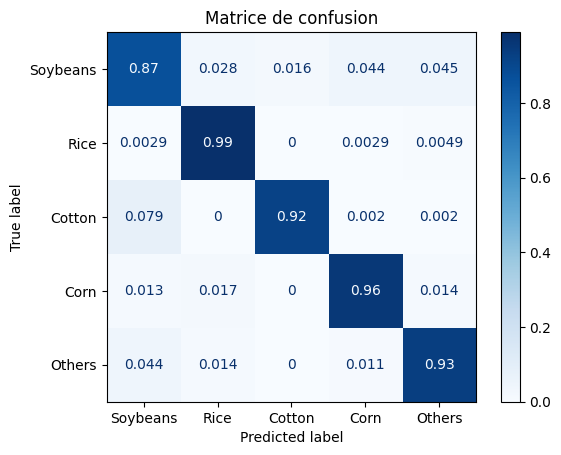


Classification Report :

              precision    recall  f1-score   support

           0       0.60      0.93      0.73       365
           1       0.85      0.96      0.90      1201
           2       0.87      0.92      0.89       494
           3       0.93      0.99      0.96      2041
           4       0.98      0.87      0.92      4380

    accuracy                           0.91      8481
   macro avg       0.85      0.93      0.88      8481
weighted avg       0.93      0.91      0.92      8481



In [29]:
# Confusion Matrix 
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_a_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_a_test, y_a_pred))

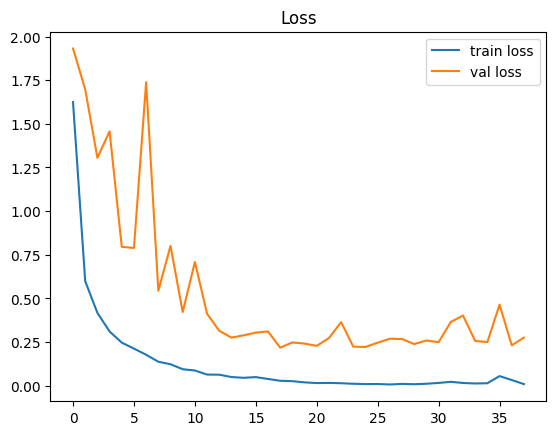

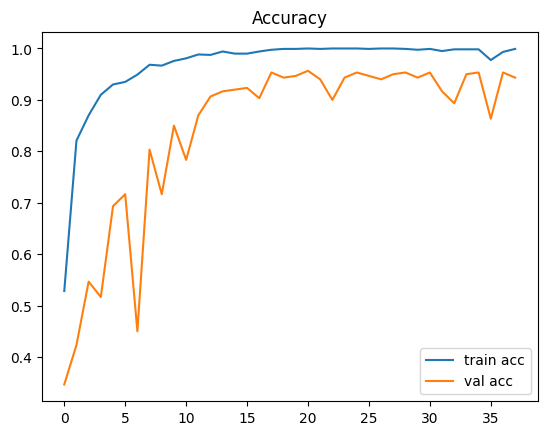

In [30]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

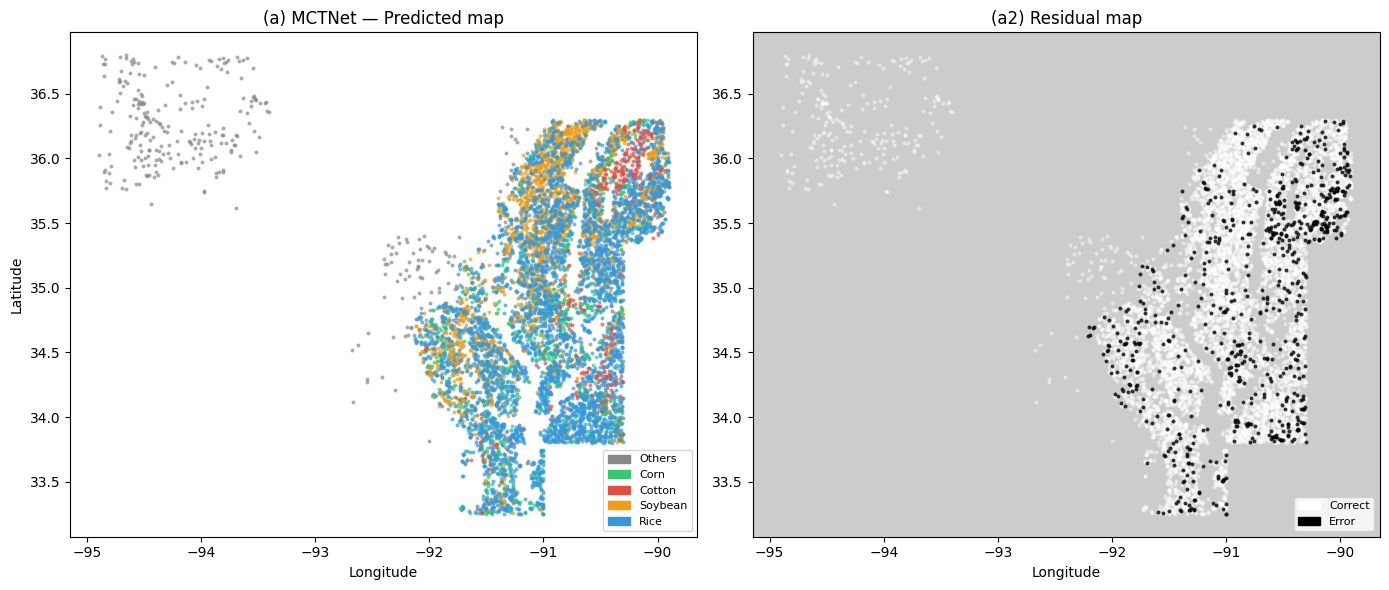

Mapping accuracy : 0.915


In [31]:



def split_par_classe_avec_index_a(df, X, y, mask, n_per_class=300, val_ratio=0.2, random_state=42):
    train_idx, val_idx, test_idx = [], [], []

    for classe in np.unique(y):
        idx_classe = np.where(y == classe)[0]
        idx_trainval, idx_test = train_test_split(
            idx_classe, train_size=n_per_class,
            random_state=random_state, shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_ratio,
            random_state=random_state, shuffle=True
        )
        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    return (
        X[train_idx], X[val_idx], X[test_idx],
        y[train_idx], y[val_idx], y[test_idx],
        mask[train_idx], mask[val_idx], mask[test_idx],
        test_idx  
    )


(X_a_train, X_a_val, X_a_test,
 y_a_train, y_a_val, y_a_test,
 mask_a_train, mask_a_val, mask_a_test,
 test_idx) = split_par_classe_avec_index_a(df_a, X_a, y_a, mask_a)


coords_test = df_a.iloc[test_idx][['latitude', 'longitude']].values



LABEL_MAP = {
    0: 'Others',
    1: 'Corn',
    2: 'Cotton',
    3: 'Soybean',
    4: 'Rice',
}

COLOR_MAP = {
    0: '#888888',   # Others  → gris
    1: '#2ecc71',   # Corn    → vert
    2: '#e74c3c',   # Cotton  → rouge
    3: '#f39c12',   # Soybean → orange
    4: '#3498db',   # Rice    → bleu
}


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lats = coords_test[:, 0]
lons = coords_test[:, 1]


ax = axes[0]
for classe, color in COLOR_MAP.items():
    mask_classe = y_a_pred == classe
    if mask_classe.sum() > 0:
        ax.scatter(
            lons[mask_classe], lats[mask_classe],
            c=color, s=8, label=LABEL_MAP[classe],
            alpha=0.7, linewidths=0
        )

ax.set_title('(a) MCTNet — Predicted map', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')


patches = [mpatches.Patch(color=COLOR_MAP[c], label=LABEL_MAP[c])
           for c in COLOR_MAP]
ax.legend(handles=patches, loc='lower right', fontsize=8, markerscale=3)


ax = axes[1]
correct = y_a_pred == y_a_test

ax.scatter(
    lons[correct], lats[correct],
    c='white', s=8, alpha=0.5, linewidths=0,
    label='Correct'
)
ax.scatter(
    lons[~correct], lats[~correct],
    c='black', s=8, alpha=0.8, linewidths=0,
    label='Error'
)

ax.set_facecolor('#cccccc')  
ax.set_title('(a2) Residual map', fontsize=12)
ax.set_xlabel('Longitude')

patches_res = [
    mpatches.Patch(color='white', label='Correct'),
    mpatches.Patch(color='black', label='Error')
]
ax.legend(handles=patches_res, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('crop_map_arkansas.png', dpi=300, bbox_inches='tight')
plt.show()


mapping_accuracy = correct.sum() / len(correct)
print(f"Mapping accuracy : {mapping_accuracy:.3f}")


In [32]:
#3.2 CALIFORNIA

In [33]:
print(df_c.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [ ]:
X_c = df_c.drop(columns=['crop_label','latitude','longitude','crop_name']).values

df_c_y = df_c[['crop_label']].copy()

keep = [3, 36, 69, 75, 204]


df_c_y['crop_label'] = df_c_y['crop_label'].apply(lambda x: x if x in keep else 0)

# remap
df_c_y['crop_label'] = df_c_y['crop_label'].replace({
    3: 1,
    36: 2,
    69: 3,
    75: 4,
    204: 5
})

y_c = df_c_y['crop_label'].values

print(sorted(np.unique(y_c)))



[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
#reshape
X_c = X_c.reshape(-1, 36, 10)       
mask_c = (X_c != 0).astype(float)    

X_max = X_c.max(axis=(0, 1), keepdims=True)
X_max[X_max == 0] = 1
X_c = X_c / X_max

In [36]:
(X_c_train, X_c_val, X_c_test,
 y_c_train, y_c_val, y_c_test,
 mask_c_train, mask_c_val, mask_c_test) = split_par_classe(
    df_c, X_c, y_c,
    mask=mask_c,
    n_per_class=300,
    val_ratio=0.2,
    random_state=42
)

In [ ]:
def build_MCTNet_c(input_shape=(36, 10), num_classes=6):
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    x = CTFusion(inputs, mask=mask, use_alpe=True)  
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  
    x = layers.GlobalMaxPooling1D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

In [38]:
model_c = build_MCTNet_c()

model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_c.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 36, 10)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 36, 10)    │          0 │ lambda_1[0][0],   │
│ (Multiply)          │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 36, 10)    │        310 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_8[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 10, 1)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 10, 1)     │          3 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 1)     │          0 │ conv1d_9[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 10)     │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 36, 10)    │          0 │ conv1d_8[0][0],   │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 36, 10)    │          0 │ multiply_3[0][0], │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add_10[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 36, 10)    │        310 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 36, 10)    │          0 │ add_10[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 36, 10)    │        310 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 61,839 (241.56 KB)

 Trainable params: 61,559 (240.46 KB)

 Non-trainable params: 280 (1.09 KB)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_c = model_c.fit(
    [X_c_train, mask_c_train], y_c_train,
    validation_data=([X_c_val, mask_c_val], y_c_val),
    epochs=200, batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 141s 344ms/step - accuracy: 0.6542 - loss: 1.0677 - val_accuracy: 0.4611 - val_loss: 1.6199
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8569 - loss: 0.4668 - val_accuracy: 0.4472 - val_loss: 1.6475
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8847 - loss: 0.3511 - val_accuracy: 0.3361 - val_loss: 2.0011
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9076 - loss: 0.2807 - val_accuracy: 0.4472 - val_loss: 1.7825
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9243 - loss: 0.2415 - val_accuracy: 0.4639 - val_loss: 1.5611
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9312 - loss: 0.2092 - val_accuracy: 0.5583 - val_loss: 1.0856
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9458 - loss: 0.1793 - val_accuracy: 0.7722 - val_loss: 0.6248
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9500 - loss: 0.1690 - val_accuracy

In [40]:
y_c_pred = model_c.predict([X_c_test, mask_c_test])
y_c_pred = y_c_pred.argmax(axis=1)

oa = accuracy_score(y_c_test, y_c_pred)
f1 = f1_score(y_c_test, y_c_pred, average='macro')
kappa = cohen_kappa_score(y_c_test, y_c_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)

257/257 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step
OA: 0.9239024390243903
F1: 0.8865261822417665
Kappa: 0.8992625978059218


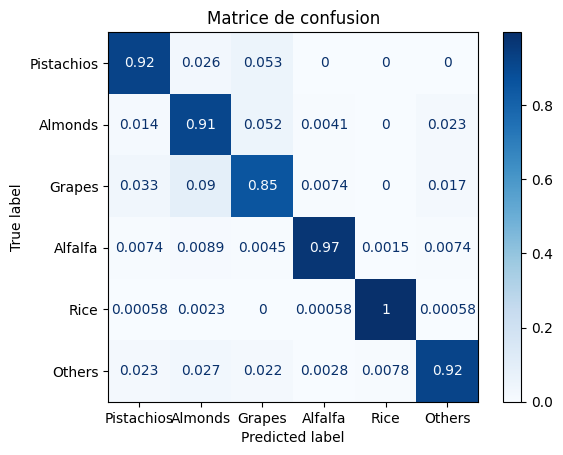


Classification Report :

              precision    recall  f1-score   support

           0       0.60      0.93      0.73       365
           1       0.85      0.96      0.90      1201
           2       0.87      0.92      0.89       494
           3       0.93      0.99      0.96      2041
           4       0.98      0.87      0.92      4380

    accuracy                           0.91      8481
   macro avg       0.85      0.93      0.88      8481
weighted avg       0.93      0.91      0.92      8481



In [41]:
# Confusion Matrix 
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_c_test, y_c_pred,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

print("\nClassification Report :\n")
print(classification_report(y_a_test, y_a_pred))

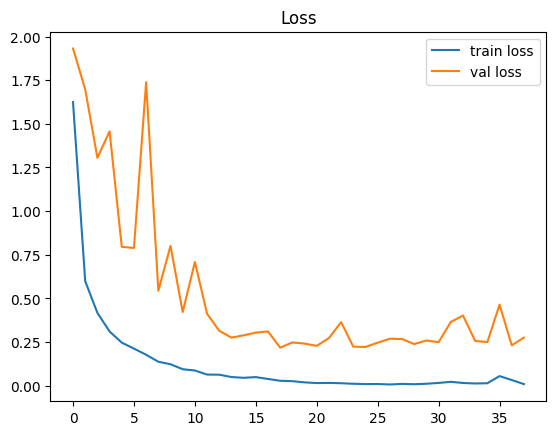

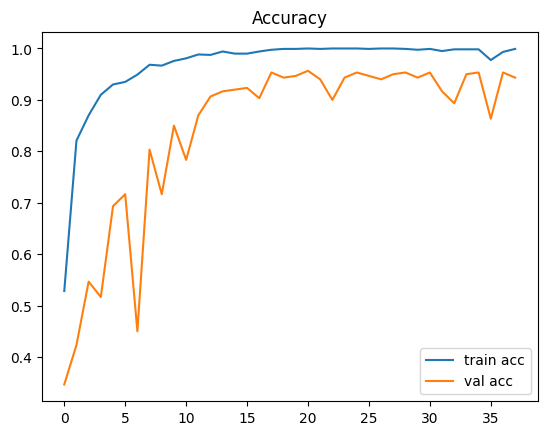

In [42]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

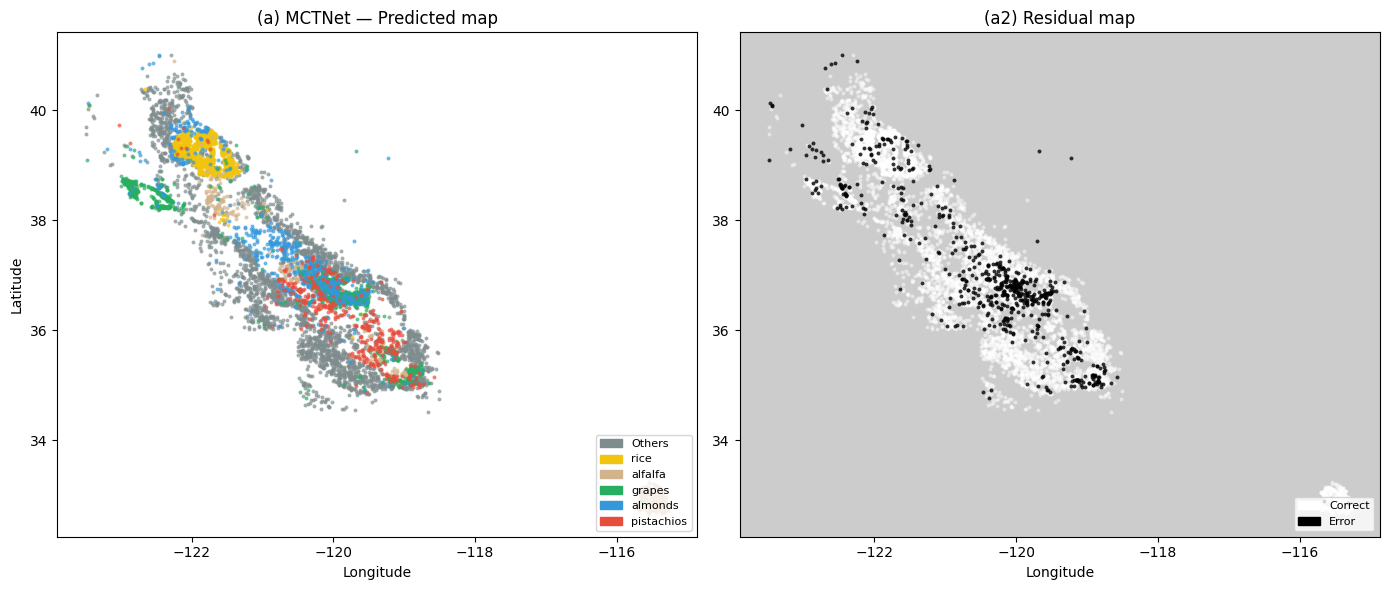

Mapping accuracy : 0.924


In [44]:



def split_par_classe_avec_index_c(df, X, y, mask, n_per_class=300, val_ratio=0.2, random_state=42):
    train_idx, val_idx, test_idx = [], [], []

    for classe in np.unique(y):
        idx_classe = np.where(y == classe)[0]
        idx_trainval, idx_test = train_test_split(
            idx_classe, train_size=n_per_class,
            random_state=random_state, shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_ratio,
            random_state=random_state, shuffle=True
        )
        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    return (
        X[train_idx], X[val_idx], X[test_idx],
        y[train_idx], y[val_idx], y[test_idx],
        mask[train_idx], mask[val_idx], mask[test_idx],
        test_idx  
    )


(X_c_train, X_c_val, X_c_test,
 y_c_train, y_c_val, y_c_test,
 mask_c_train, mask_c_val, mask_c_test,
 test_idx) = split_par_classe_avec_index_c(df_c, X_c, y_c, mask_c)


coords_test = df_c.iloc[test_idx][['latitude', 'longitude']].values








LABEL_MAP = {
    0: 'Others',
    1: 'rice',
    2: 'alfalfa',
    3: 'grapes',
    4: 'almonds',
    5: 'pistachios'
}

COLOR_MAP = {
    0: '#7f8c8d',  
    1: '#f1c40f',  
    2: '#d2b48c',  
    3: '#27ae60',  
    4: '#3498db',  
    5: '#e74c3c',  
}


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lats = coords_test[:, 0]
lons = coords_test[:, 1]


ax = axes[0]
for classe, color in COLOR_MAP.items():
    mask_classe = y_c_pred == classe
    if mask_classe.sum() > 0:
        ax.scatter(
            lons[mask_classe], lats[mask_classe],
            c=color, s=8, label=LABEL_MAP[classe],
            alpha=0.7, linewidths=0
        )

ax.set_title('(a) MCTNet — Predicted map', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')


patches = [mpatches.Patch(color=COLOR_MAP[c], label=LABEL_MAP[c])
           for c in COLOR_MAP]
ax.legend(handles=patches, loc='lower right', fontsize=8, markerscale=3)


ax = axes[1]
correct = y_c_pred == y_c_test

ax.scatter(
    lons[correct], lats[correct],
    c='white', s=8, alpha=0.5, linewidths=0,
    label='Correct'
)
ax.scatter(
    lons[~correct], lats[~correct],
    c='black', s=8, alpha=0.8, linewidths=0,
    label='Error'
)

ax.set_facecolor('#cccccc')  
ax.set_title('(a2) Residual map', fontsize=12)
ax.set_xlabel('Longitude')

patches_res = [
    mpatches.Patch(color='white', label='Correct'),
    mpatches.Patch(color='black', label='Error')
]
ax.legend(handles=patches_res, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('crop_map_arkansas.png', dpi=300, bbox_inches='tight')
plt.show()


mapping_accuracy = correct.sum() / len(correct)
print(f"Mapping accuracy : {mapping_accuracy:.3f}")
